In [7]:
import pandas as pd
from pathlib import Path

In [8]:
DATA_DIR = Path("/Users/maxim.popov/repos/nebulastream/cmake-build-release-docker/nes-systests/testdata/large/nexmark")
BID_FILE = "bid_6GB.csv"
PERSON_FILE = "person_840MB.csv"
AUCTION_FILE = "auction_707.csv"

In [9]:
bid = pd.read_csv(DATA_DIR / BID_FILE, names=["timestamp", "auctionId", "bidder", "price"])
bid.head()

,timestamp,auctionId,bidder,price
0,1746560847787,1000,1001,73134520
1,1746560847788,1000,1001,1940
2,1746560847788,1000,1001,2419091
3,1746560847788,1000,1001,43672280
4,1746560847788,1000,1001,499920


In [10]:
print(f"uniques values: {len(bid['timestamp'].unique())}")

uniques values: 16944703


In [11]:
person = pd.read_csv(DATA_DIR / PERSON_FILE, names=["id", "name", "email_address", "credit_card", "city", "state", "timestamp", "extra"])

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.labelcolor": "black",
    "ytick.labelcolor": "black",
})


def summarize_numeric(series: pd.Series) -> pd.Series:
    return pd.Series({
        "count": series.count(),
        "unique": series.nunique(),
        "min": series.min(),
        "p1": series.quantile(0.01),
        "p25": series.quantile(0.25),
        "median": series.median(),
        "mean": series.mean(),
        "p75": series.quantile(0.75),
        "p99": series.quantile(0.99),
        "max": series.max(),
        "std": series.std(),
    })


def summarize_string(series: pd.Series) -> pd.Series:
    lens = series.astype(str).str.len()
    return pd.Series({
        "count": series.count(),
        "unique": series.nunique(),
        "len_min": lens.min(),
        "len_mean": lens.mean(),
        "len_median": lens.median(),
        "len_max": lens.max(),
        "len_std": lens.std(),
        "total_bytes": int(lens.sum()),
    })

## Bid dataset — value distributions

In [14]:
bid_summary = pd.DataFrame({c: summarize_numeric(bid[c]) for c in bid.columns})
bid_summary.round(2)

,timestamp,auctionId,bidder,price
count,1.839917e+08,1.839917e+08,1.839917e+08,1.839917e+08
unique,1.694470e+07,1.199451e+07,3.999872e+06,5.190904e+06
min,1.746561e+12,1.000000e+03,1.000000e+03,1.000000e+02
p1,1.746561e+12,1.209510e+05,4.080100e+04,1.150000e+02
p25,1.746566e+12,3.000900e+06,1.000801e+06,3.165000e+03
median,1.746571e+12,6.000900e+06,2.000801e+06,1.000760e+05
mean,1.746571e+12,6.000907e+06,2.000824e+06,7.238426e+06
p75,1.746576e+12,9.000900e+06,3.000801e+06,3.163542e+06
p99,1.746581e+12,1.188095e+07,3.960801e+06,8.708843e+07
max,1.746581e+12,1.200101e+07,4.000994e+06,9.999989e+07


In [15]:
# Bid: top-K value frequencies (how skewed is each column?)
def top_k_table(series: pd.Series, k: int = 10) -> pd.DataFrame:
    vc = series.value_counts()
    total = vc.sum()
    head = vc.head(k).rename("count").to_frame()
    head["pct"] = (head["count"] / total * 100).round(3)
    head["cum_pct"] = head["pct"].cumsum().round(3)
    return head

for col in ["auctionId", "bidder", "price"]:
    print(f"=== bid.{col}  (unique={bid[col].nunique():,}) ===")
    print(top_k_table(bid[col]))
    print()

=== bid.auctionId  (unique=11,994,511) ===
           count  pct  cum_pct
auctionId                     
5904600      873  0.0      0.0
885300       871  0.0      0.0
2997900      864  0.0      0.0
10005300     860  0.0      0.0
213300       860  0.0      0.0
7446000      860  0.0      0.0
9384600      859  0.0      0.0
11901900     859  0.0      0.0
10695000     859  0.0      0.0
6357300      858  0.0      0.0

=== bid.bidder  (unique=3,999,872) ===
         count    pct  cum_pct
bidder                        
3944701   3580  0.002    0.002
1467201   3572  0.002    0.004
88801     3572  0.002    0.006
1856101   3571  0.002    0.008
2077401   3570  0.002    0.010
105501    3570  0.002    0.012
3558601   3567  0.002    0.014
494401    3566  0.002    0.016
2784101   3566  0.002    0.018
1599901   3563  0.002    0.020

=== bid.price  (unique=5,190,904) ===
        count    pct  cum_pct
price                        
101    131438  0.071    0.071
102    130279  0.071    0.142
103    128699 

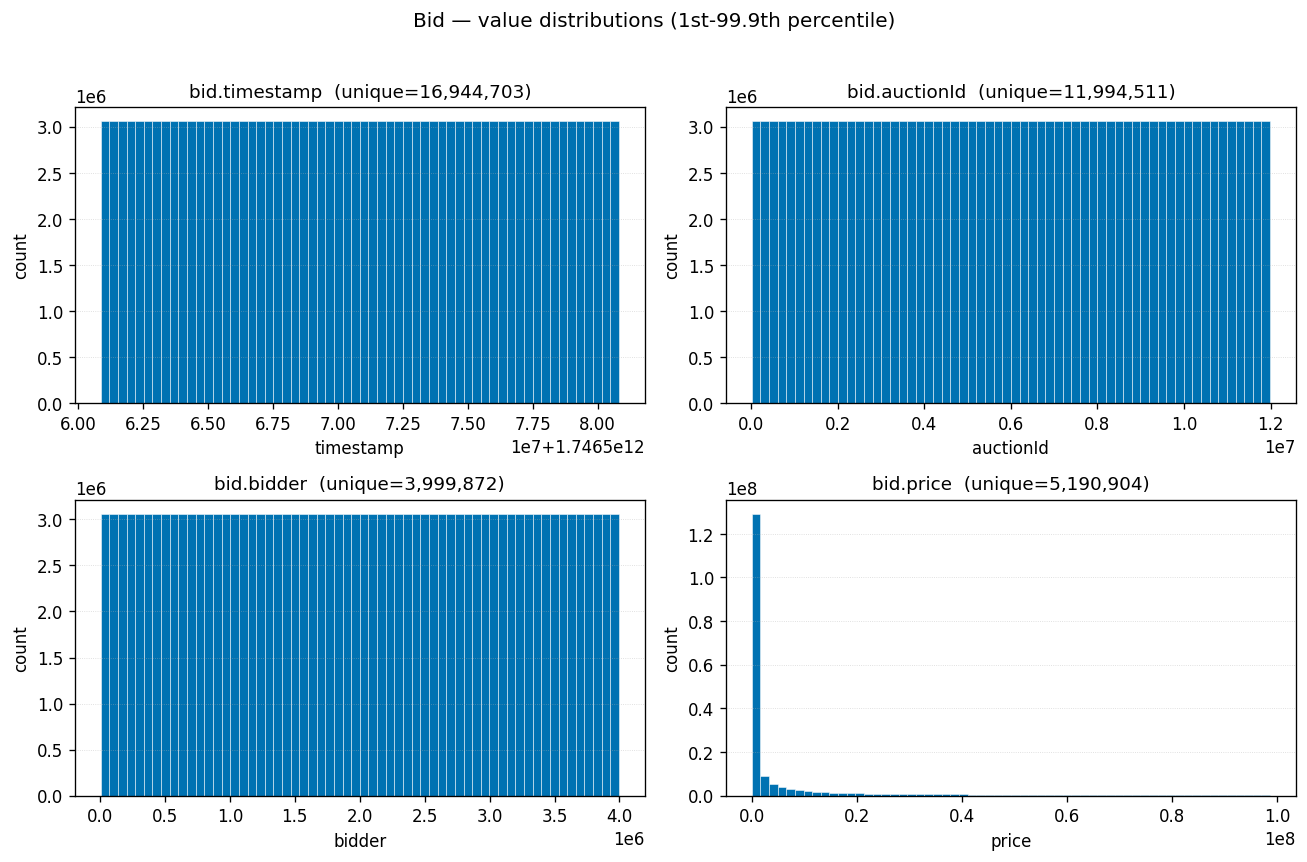

In [16]:
# Bid: histograms of numeric columns
bid_numeric_cols = ["timestamp", "auctionId", "bidder", "price"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7), dpi=120)
for ax, col in zip(axes.flat, bid_numeric_cols):
    data = bid[col].dropna().values
    # Clip to 99.9% to keep extreme tails from squashing the histogram
    hi = np.quantile(data, 0.999)
    lo = np.quantile(data, 0.001)
    clipped = data[(data >= lo) & (data <= hi)]
    ax.hist(clipped, bins=60, color="#0072B2", edgecolor="white", linewidth=0.3)
    ax.set_title(f"bid.{col}  (unique={bid[col].nunique():,})")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.suptitle("Bid — value distributions (1st-99.9th percentile)", y=1.02)
fig.tight_layout()
plt.show()

## Person dataset — value distributions

In [17]:
person_numeric_cols = ["id", "timestamp"]
person_string_cols  = ["name", "email_address", "credit_card", "city", "state", "extra"]

num_summary = pd.DataFrame({c: summarize_numeric(person[c]) for c in person_numeric_cols})
str_summary = pd.DataFrame({c: summarize_string(person[c])  for c in person_string_cols})
print("--- numeric ---")
display(num_summary.round(2))
print("--- string ---")
display(str_summary.round(2))

--- numeric ---


,id,timestamp
count,4000000.00,4.000000e+06
unique,4000000.00,4.000000e+06
min,1000.00,1.746561e+12
p1,40999.99,1.746561e+12
p25,1000999.75,1.746566e+12
median,2000999.50,1.746571e+12
mean,2000999.50,1.746571e+12
p75,3000999.25,1.746576e+12
p99,3960999.01,1.746581e+12
max,4000999.00,1.746581e+12


--- string ---


,name,email_address,credit_card,city,state,extra
count,4000000.00,4000000.0,4000000.0,4000000.00,4000000.0,4.000000e+06
unique,99.00,4000000.0,4000000.0,10.00,6.0,4.000000e+06
len_min,10.00,17.0,19.0,4.00,2.0,1.020000e+02
len_mean,11.50,17.0,19.0,7.40,2.0,1.346100e+02
len_median,11.00,17.0,19.0,7.00,2.0,1.350000e+02
len_max,14.00,17.0,19.0,13.00,2.0,1.670000e+02
len_std,1.09,0.0,0.0,2.73,0.0,1.588000e+01
total_bytes,46017535.00,68000000.0,76000000.0,29597123.00,8000000.0,5.384334e+08


In [18]:
# Person: top-K value frequencies per string column
for col in person_string_cols:
    print(f"=== person.{col}  (unique={person[col].nunique():,}, "
          f"NaN={person[col].isna().sum():,}) ===")
    print(top_k_table(person[col]))
    print()

=== person.name  (unique=99, NaN=0) ===
               count    pct  cum_pct
name                                
saul smith     40829  1.021    1.021
paul white     40743  1.019    2.040
saul jones     40729  1.018    3.058
john abrams    40692  1.017    4.075
peter bartels  40684  1.017    5.092
peter white    40675  1.017    6.109
vicky bartels  40670  1.017    7.126
kate smith     40652  1.016    8.142
paul jones     40621  1.016    9.158
sarah walton   40621  1.016   10.174

=== person.email_address  (unique=4,000,000, NaN=0) ===
                   count  pct  cum_pct
email_address                         
yplkvgz@qbxfg.com      1  0.0      0.0
pdatcjy@bueds.com      1  0.0      0.0
rlrefmn@ftnrs.com      1  0.0      0.0
vlaydil@ieupg.com      1  0.0      0.0
gkvwiuw@xyxei.com      1  0.0      0.0
hkhvwrc@wbtlg.com      1  0.0      0.0
vnnzdgu@rklxq.com      1  0.0      0.0
gnwurfd@givld.com      1  0.0      0.0
hnjqkrt@rommz.com      1  0.0      0.0
yuclvaa@tysic.com      1  0.0 

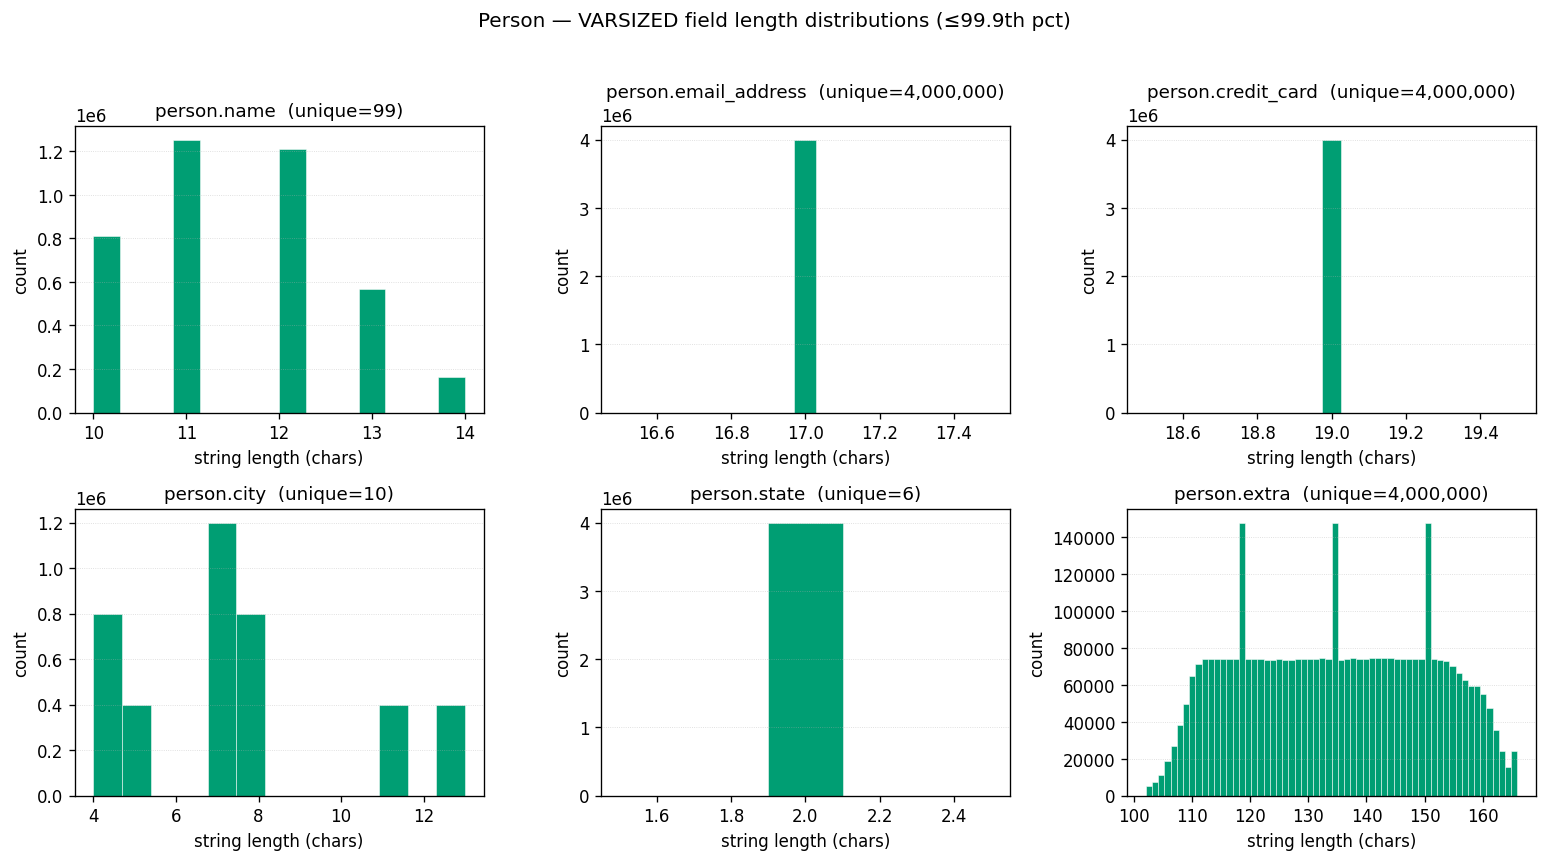

In [19]:
# Person: string length distributions (VARSIZED fields dominate the on-disk size)
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=120)
for ax, col in zip(axes.flat, person_string_cols):
    lens = person[col].astype(str).str.len()
    hi = int(np.quantile(lens, 0.999))
    clipped = lens[lens <= hi]
    ax.hist(clipped, bins=min(60, max(5, hi)),
            color="#009E73", edgecolor="white", linewidth=0.3)
    ax.set_title(f"person.{col}  (unique={person[col].nunique():,})")
    ax.set_xlabel("string length (chars)")
    ax.set_ylabel("count")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.suptitle("Person — VARSIZED field length distributions (≤99.9th pct)", y=1.02)
fig.tight_layout()
plt.show()

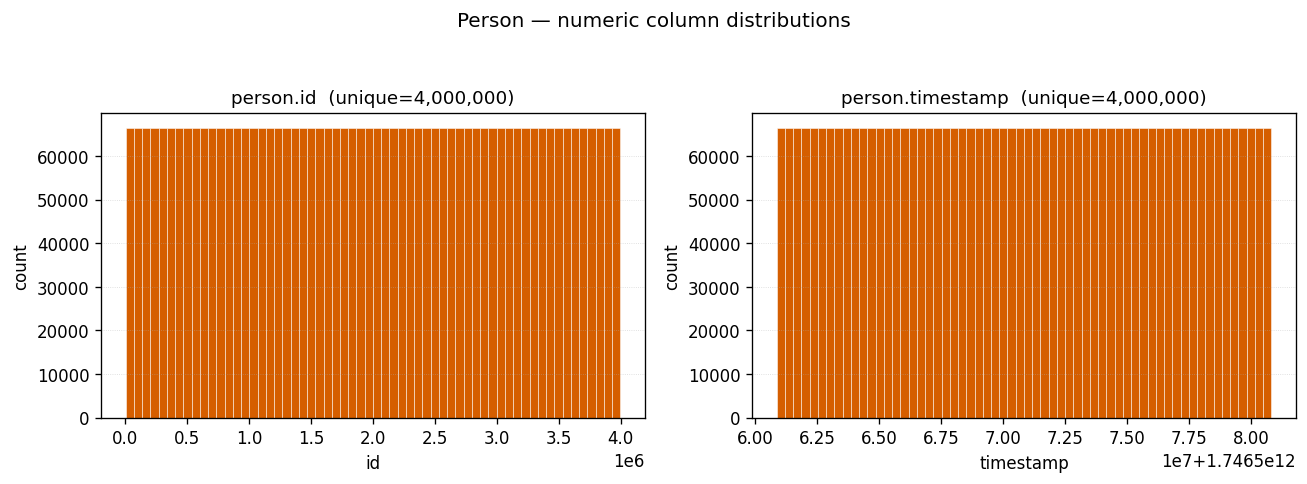

In [20]:
# Person: numeric columns (id, timestamp) — histograms
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), dpi=120)
for ax, col in zip(axes.flat, person_numeric_cols):
    data = person[col].dropna().values
    hi = np.quantile(data, 0.999)
    lo = np.quantile(data, 0.001)
    clipped = data[(data >= lo) & (data <= hi)]
    ax.hist(clipped, bins=60, color="#D55E00", edgecolor="white", linewidth=0.3)
    ax.set_title(f"person.{col}  (unique={person[col].nunique():,})")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.suptitle("Person — numeric column distributions", y=1.05)
fig.tight_layout()
plt.show()

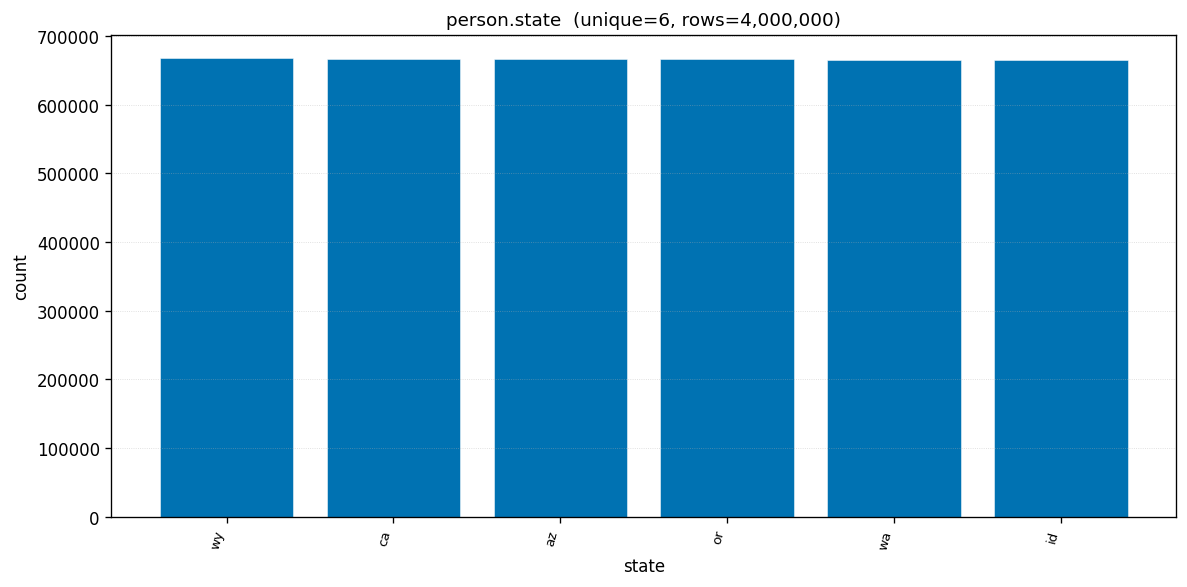

In [21]:
# person.state — frequency distribution (all values)
state_counts = person["state"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.bar(range(len(state_counts)), state_counts.values,
       color="#0072B2", edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(state_counts)))
ax.set_xticklabels(state_counts.index, rotation=75, ha="right", fontsize=8)
ax.set_title(f"person.state  (unique={len(state_counts):,}, rows={state_counts.sum():,})")
ax.set_xlabel("state")
ax.set_ylabel("count")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()

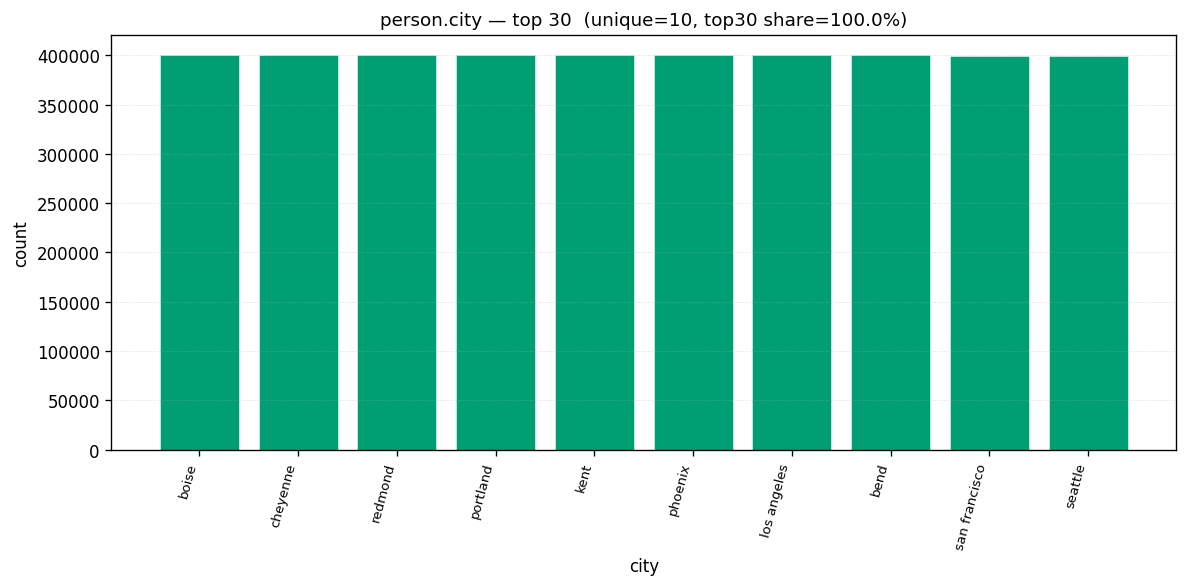

In [22]:
# person.city — top-N + "other"
city_counts = person["city"].value_counts()
TOP_CITIES = 30
top_cities = city_counts.head(TOP_CITIES)
other_cities_total = int(city_counts.iloc[TOP_CITIES:].sum())

labels = list(top_cities.index) + (["<other>"] if other_cities_total else [])
values = list(top_cities.values) + ([other_cities_total] if other_cities_total else [])
colors = ["#009E73"] * len(top_cities) + (["#888888"] if other_cities_total else [])

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.bar(range(len(labels)), values, color=colors, edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=8)
ax.set_title(
    f"person.city — top {TOP_CITIES}  (unique={city_counts.size:,}, "
    f"top{TOP_CITIES} share={top_cities.sum()/city_counts.sum()*100:.1f}%)"
)
ax.set_xlabel("city")
ax.set_ylabel("count")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()

unique cities:              10
unique states:              6
unique (city, state) pairs: 60
cartesian  cities × states: 60  (joint density = 100.00%)
states per city   — min=6, median=6, mean=6.00, max=6
cities per state  — min=10, median=10, mean=10.0, max=10


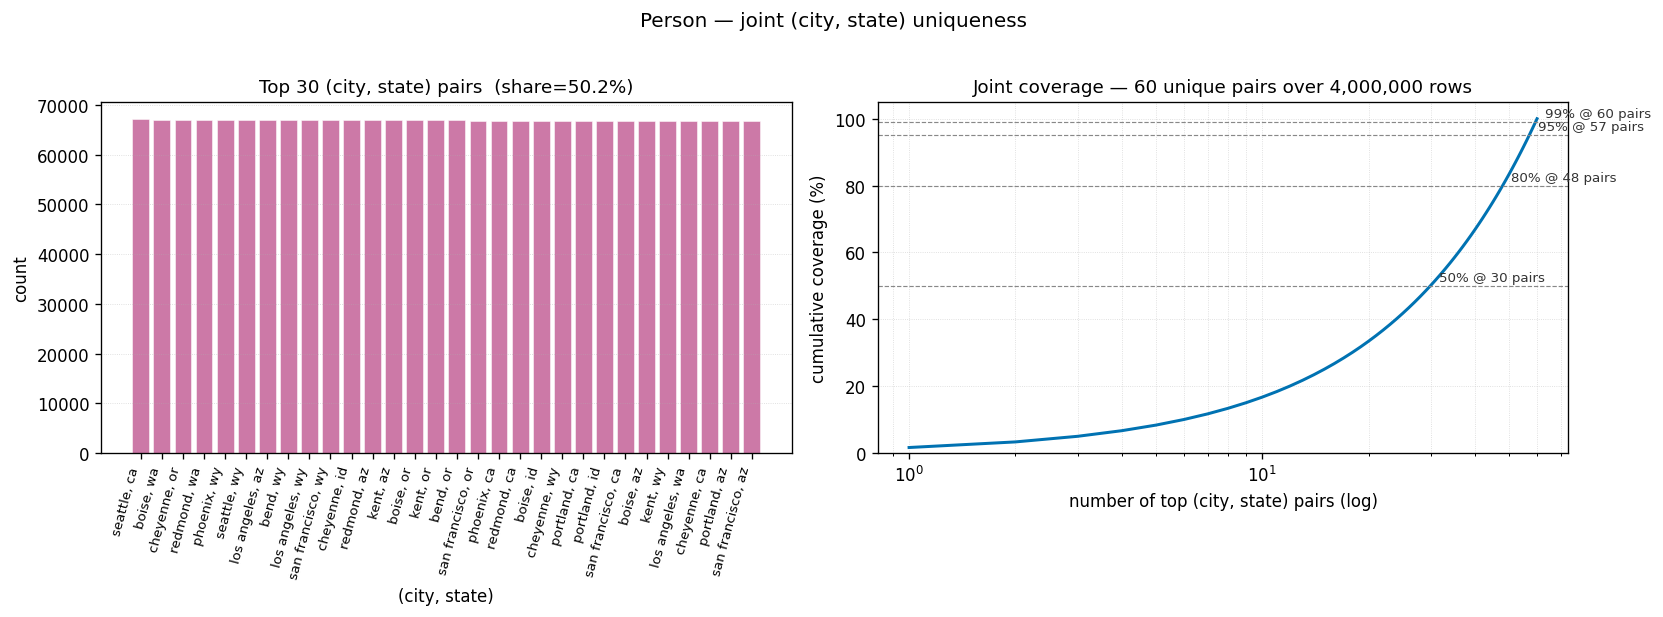

In [23]:
# Joint uniqueness of (city, state)
pair_counts = person.groupby(["city", "state"]).size().sort_values(ascending=False)

n_cities     = person["city"].nunique()
n_states     = person["state"].nunique()
n_pairs      = len(pair_counts)
n_rows_total = int(pair_counts.sum())
cartesian    = n_cities * n_states

# How many distinct states does each city appear with? (and vice versa)
states_per_city = person.groupby("city")["state"].nunique()
cities_per_state = person.groupby("state")["city"].nunique()

print(f"unique cities:              {n_cities:,}")
print(f"unique states:              {n_states:,}")
print(f"unique (city, state) pairs: {n_pairs:,}")
print(f"cartesian  cities × states: {cartesian:,}  "
      f"(joint density = {n_pairs / cartesian * 100:.2f}%)")
print(f"states per city   — min={states_per_city.min()}, "
      f"median={states_per_city.median():.0f}, mean={states_per_city.mean():.2f}, "
      f"max={states_per_city.max()}")
print(f"cities per state  — min={cities_per_state.min()}, "
      f"median={cities_per_state.median():.0f}, mean={cities_per_state.mean():.1f}, "
      f"max={cities_per_state.max()}")

TOP_PAIRS = 30
top_pairs = pair_counts.head(TOP_PAIRS)
pair_labels = [f"{c}, {s}" for c, s in top_pairs.index]
cumulative = pair_counts.cumsum() / n_rows_total * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# --- Left: top-N (city, state) pairs ---
ax = axes[0]
ax.bar(range(len(top_pairs)), top_pairs.values,
       color="#CC79A7", edgecolor="white", linewidth=0.3)
ax.set_xticks(range(len(top_pairs)))
ax.set_xticklabels(pair_labels, rotation=75, ha="right", fontsize=8)
ax.set_title(f"Top {TOP_PAIRS} (city, state) pairs  "
             f"(share={top_pairs.sum()/n_rows_total*100:.1f}%)")
ax.set_xlabel("(city, state)")
ax.set_ylabel("count")
ax.grid(True, axis="y", linestyle=":", alpha=0.5)

# --- Right: cumulative coverage of pairs ---
ax = axes[1]
ax.plot(np.arange(1, len(cumulative) + 1), cumulative.values,
        color="#0072B2", linewidth=1.8)
ax.set_xscale("log")
ax.set_xlabel("number of top (city, state) pairs (log)")
ax.set_ylabel("cumulative coverage (%)")
ax.set_title(f"Joint coverage — {n_pairs:,} unique pairs over {n_rows_total:,} rows")
ax.set_ylim(0, 105)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
for pct in (50, 80, 95, 99):
    k = int(np.searchsorted(cumulative.values, pct)) + 1
    ax.axhline(pct, color="#888", linestyle="--", linewidth=0.7)
    ax.annotate(f"{pct}% @ {k:,} pairs", xy=(k, pct), xytext=(5, 3),
                textcoords="offset points", fontsize=8, color="#333")

fig.suptitle("Person — joint (city, state) uniqueness", y=1.02)
fig.tight_layout()
plt.show()

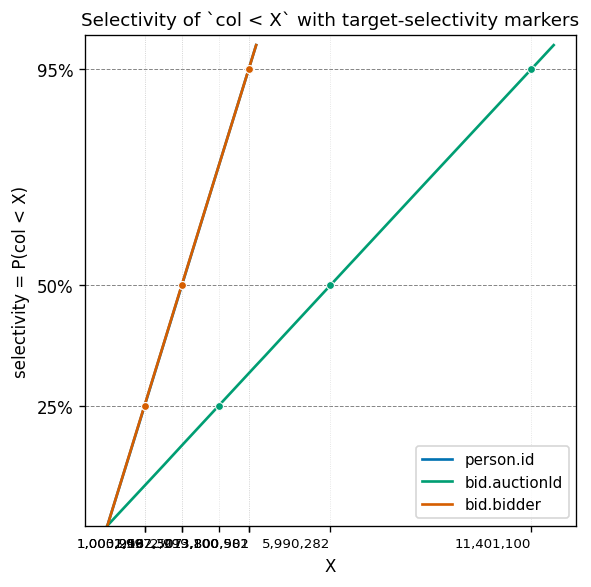

X values that give target selectivity for `col < X`:


,25%,50%,95%
column,,,
person.id,1003958.0,2002507.0,3800582.25
bid.auctionId,2999100.0,5990282.0,11401100.00
bid.bidder,1000216.5,1997301.0,3800901.00


In [30]:
# Selectivity of `col < X` filters — empirical CDF of id-like numeric columns.
# Useful for picking X that targets a given selectivity in lazy-parsing experiments.

SELECTIVITY_COLUMNS = [
    ("person.id",        person["id"]),
    ("bid.auctionId",    bid["auctionId"]),
    ("bid.bidder",       bid["bidder"]),
]

SAMPLE_N = 1_000_000

def cdf_xy(series: pd.Series, n_points: int = 400) -> tuple[np.ndarray, np.ndarray]:
    s = series.dropna()
    if len(s) > SAMPLE_N:
        s = s.sample(SAMPLE_N, random_state=0)
    values = np.sort(s.to_numpy())
    n = len(values)
    sel_full = np.arange(n) / n
    if n > n_points:
        idx = np.linspace(0, n - 1, n_points).astype(int)
        values = values[idx]
        sel = sel_full[idx]
    else:
        sel = sel_full
    return values, sel

TARGETS = [0.25, 0.5, 0.95]
palette = ["#0072B2", "#009E73", "#D55E00", "#CC79A7"]

fig, ax = plt.subplots(figsize=(5, 5), dpi=120)

# Collect target X values per column so we can tick them on the x-axis
target_x_ticks: list[float] = []

for (label, s), color in zip(SELECTIVITY_COLUMNS, palette):
    xs, ys = cdf_xy(s)
    ax.plot(xs, ys, color=color, linewidth=1.6, label=label)

    sample = s.dropna()
    if len(sample) > SAMPLE_N:
        sample = sample.sample(SAMPLE_N, random_state=0)
    qs = np.quantile(sample, TARGETS)

    # marker at each (X, target) crossing
    ax.scatter(qs, TARGETS, color=color, s=22, zorder=4,
               edgecolor="white", linewidth=0.6)
    target_x_ticks.extend(qs.tolist())

# y-ticks exactly at the selectivity targets + horizontal gridlines
ax.set_yticks(TARGETS)
ax.set_yticklabels([f"{int(t*100)}%" for t in TARGETS])
for t in TARGETS:
    ax.axhline(t, color="#888", linestyle="--", linewidth=0.6, zorder=1)

# x-ticks: the actual X values that hit each target, deduplicated & sorted
xt = sorted(set(np.round(target_x_ticks).astype(int).tolist()))
ax.set_xticks(xt)
ax.set_xticklabels([f"{int(v):,}" for v in xt], rotation=0, ha="right", fontsize=8)

ax.set_xlabel("X")
ax.set_ylabel("selectivity = P(col < X)")
ax.set_title("Selectivity of `col < X` with target-selectivity markers")
ax.set_ylim(0, 1.02)
ax.grid(True, axis="x", linestyle=":", alpha=0.4)
ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

# Table of X values at each target selectivity
print("X values that give target selectivity for `col < X`:")
rows = []
for label, s in SELECTIVITY_COLUMNS:
    row = {"column": label}
    sample = s.dropna()
    if len(sample) > SAMPLE_N:
        sample = sample.sample(SAMPLE_N, random_state=0)
    for t in TARGETS:
        row[f"{int(t*100)}%"] = np.quantile(sample, t)
    rows.append(row)
pd.DataFrame(rows).set_index("column")